# Postselection using bit-flip checks

In this guide we will learn what bit-flip checks are and how to implement them in software with ``qiskit-addon-utils``. We will start with a small, 2-qubit example to visualize the checks and discuss how they work. After we have built up some intuition, we will move on to a ``20``-qubit example where we implement checks and compare various postselection strategies.

#### What are bit-flip checks?
Bitflip checks are measurement-based tests of whether a qubit's state is likely corrupted by a non-Markovian error source. This test is done by placing a a bit-flip gate with extended duration (``xslow`` or a series of $N$ ``rx`` gates with angle $\frac{\pi}{N}$) on each qubit at the beginning of a circuit, followed by a regular ``XGate`` and measuring to ensure the state succesfully flipped from $|0\rangle \mapsto |1\rangle \mapsto |0\rangle$. This test can also be performed at the end of the circuit after each terminal measurement to ensure the device can successfully flip the measured state of the qubit from $|x\rangle \mapsto |x\oplus1\rangle$. Samples associated with failed checks may be considered unreliable, and postselecting only samples that pass all checks can boost the fidelity of the noisy distribution.

#### Strategies for postselecting based on bit-flip checks
- **Node-based postselection**: Postselect only samples for which each qubit passed its check(s). This is the strictest strategy and generally results in more samples being discarded.
- **Edge-based postselection**: For each edge in the qubits' coupling graph, ensure at least one qubit passes the check(s). This strategy is more lenient; if a qubit fails a check, the sample may still be kept if all its neighbors pass their checks.

#### Spectator qubits
One can specify "spectator" ancilla qubits that are adjacent to the qubits used to execute the original circuit. Bit-flip checks may be placed on these spectators, providing more coverage against the non-Markovian noise these checks are designed to detect.

### Part 1. Visualize bit-flip checks

Before we demonstrate the technique on a QPU, let's create a small, 2-qubit circuit and add checks to visualize how it works. We will start with a Bell state transpiled to the ``ibm_kingston`` backend QPU.

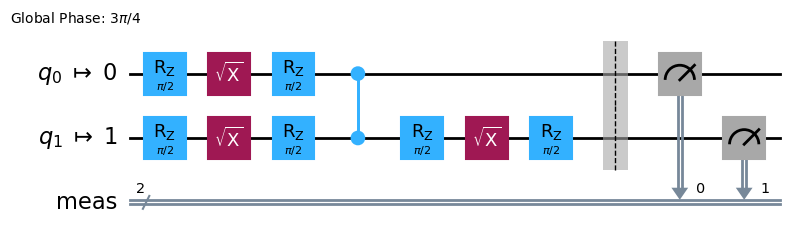

In [1]:
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform", instance="services-premium-us")
backend = service.backend("ibm_kingston")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
qc_isa = generate_preset_pass_manager(optimization_level=0, backend=backend).run(qc)
qc_isa.draw("mpl")

Now we add some bit-flip checks to the beginning of the circuit. **Checks will only be placed on qubits that are terminated with a measurement**. These checks ensure the device can successfully flip the qubit's initial state from $|0\rangle \mapsto |1\rangle \mapsto |0\rangle$, and these checks' measurements are read out in a new classical register called ``meas_pre``.

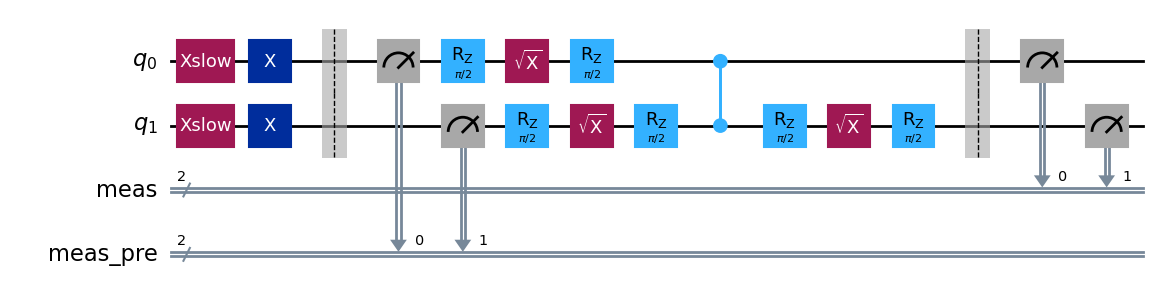

In [2]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.bit_flip_checks.passes import AddPreCircuitBitFlipChecks

qc_w_checks = PassManager([AddPreCircuitBitFlipChecks()]).run(qc_isa)
qc_w_checks.draw("mpl", idle_wires=False)

Similarly, we can add checks to the end of the circuit after each terminal measurement. These checks ensure the device can flip the qubit's state from $|x\rangle \mapsto |x\oplus1\rangle$, and their measurements are read out in a new classical register called ``meas_ps``.

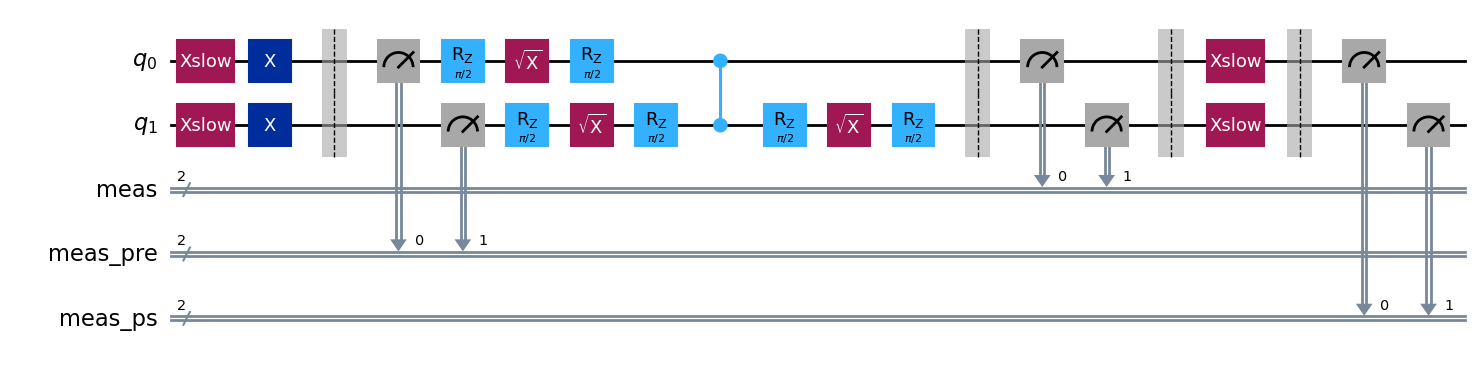

In [3]:
from qiskit_addon_utils.noise_management.bit_flip_checks.passes import AddPostCircuitBitFlipChecks

qc_w_checks = PassManager([AddPostCircuitBitFlipChecks()]).run(qc_w_checks)
qc_w_checks.draw("mpl", idle_wires=False)

As mentioned in the intro, we can use ancilla qubits that are adjacent to the data qubits as "spectators" to provide more error coverage. Here we add pre-circuit and post-circuit spectator checks. We see that since physical qubit ``2`` on ``ibm_kingston`` is adjacent to data qubit ``1``, it has been added as a spectator, and pre- and post-circuit checks have been added to it. The spectator measurements have been added to new classical registers called ``spec_pre`` and ``spec``.

A circuit such as this contains all possible bit-flip checks, so sampling from this circuit gives users the ability to postselect based on any combination of [pre/post]-circuit checks and [node/edge]-based postselection strategy. See Part 2 of this guide to see how it works on quantum hardware.

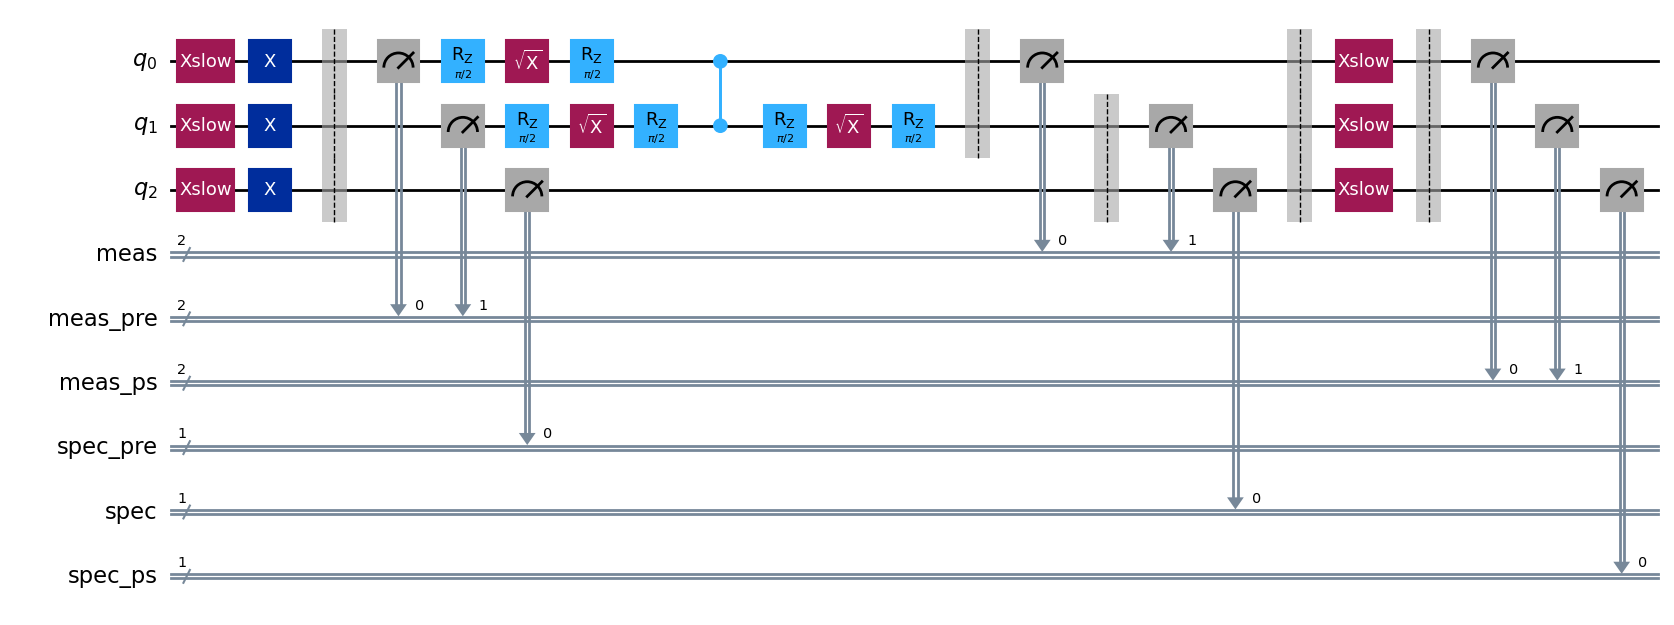

In [4]:
from qiskit_addon_utils.noise_management.bit_flip_checks.passes import (
    AddSpectatorPostCircuitBitFlipChecks,
    AddSpectatorPreCircuitBitFlipChecks,
)

qc_w_checks = PassManager(
    [
        AddSpectatorPreCircuitBitFlipChecks(coupling_map=backend.coupling_map),
        AddSpectatorPostCircuitBitFlipChecks(coupling_map=backend.coupling_map),
    ]
).run(qc_w_checks)
qc_w_checks.draw("mpl", idle_wires=False, fold=-1)

### Part 2: Demonstrate bit-flip checks on QPU and compare postselection strategies

Now that we have an understanding of what bit-flip checks are and how they are implemented in software, let's run a larger example on a QPU and see how it works.

First, we prepare a circuit. The choice of circuit isn't very important; we just want a circuit for which we can easily verify the output. Here we choose a ``20``-qubit, 1D mirrored Ising circuit. This circuit is non-trivial to execute on hardware and should be affected by non-Markovian errors, which gives us the ability to demonstrate the effectiveness of the bit-flip checks. Also, the mirrored structure allows us to trivially compare the noisy expectation value calculations against exact values.

In this experiment, we are calculating observable expectation values. The choice of observable $O$ isn't important either, so we simply choose the average single-site magnetization $O=\frac{1}{N}\sum_i\langle Z_i\rangle$.

two-qubit depth: 24
total depth:     85


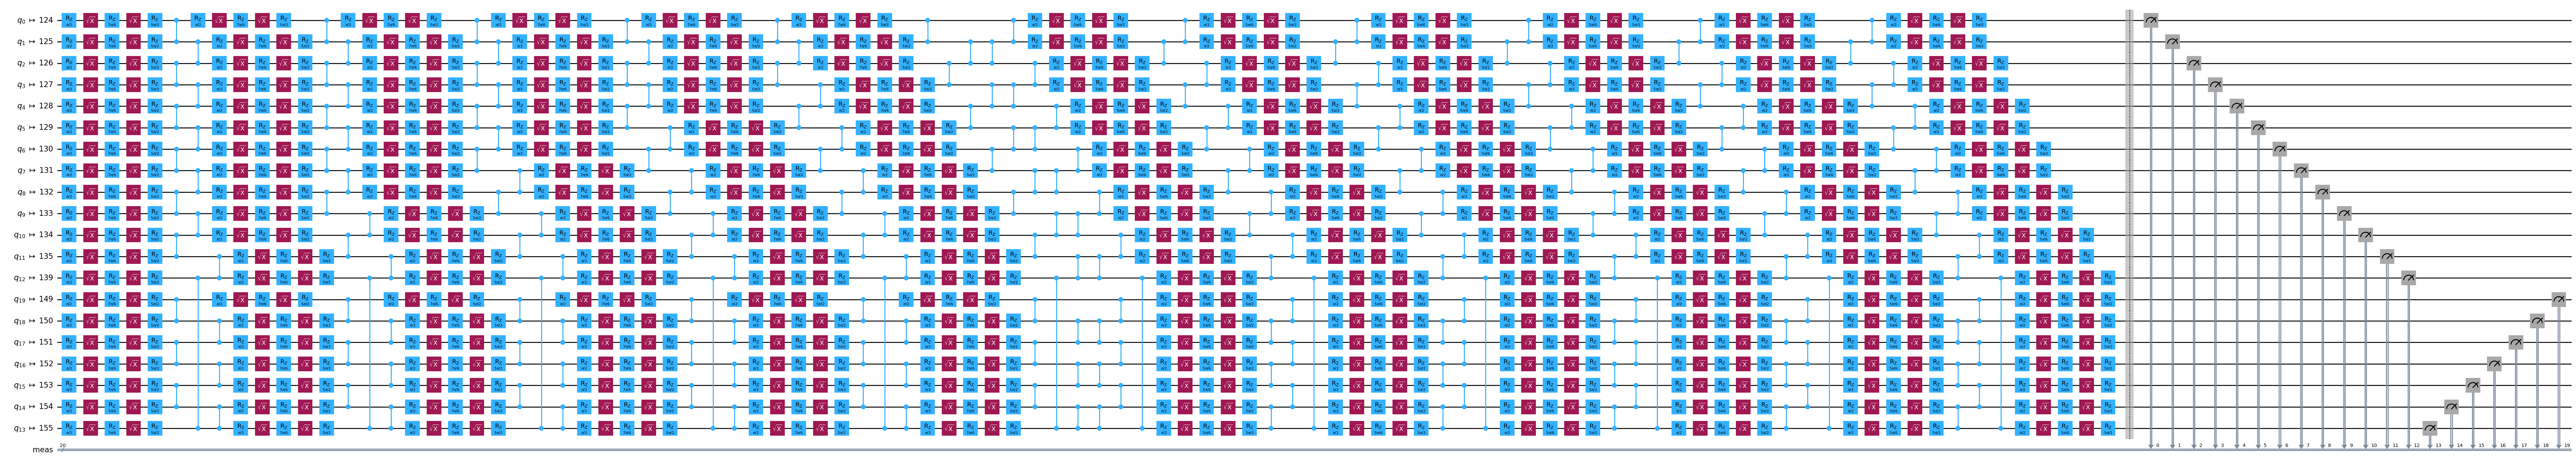

In [5]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import CouplingMap

num_qubits = 20
initial_layout = initial_layout = [
    124,
    125,
    126,
    127,
    128,
    129,
    130,
    131,
    132,
    133,
    134,
    135,
    139,
    155,
    154,
    153,
    152,
    151,
    150,
    149,
][:num_qubits]
coupling_map = CouplingMap.from_line(num_qubits, bidirectional=False)

# Num Trotter steps
num_steps = 6
theta_rx = np.pi / 6

# Average single-site magnetization
observable = (
    SparsePauliOp(["I" * iq + "Z" + "I" * (num_qubits - iq - 1) for iq in range(num_qubits)])
    / num_qubits
)

# Create the Trotter circuit
circuit = QuantumCircuit(num_qubits)
edges = CouplingMap.from_line(num_qubits, bidirectional=False).get_edges()
edges_a = [e for e in edges if e[0] % 2 == 0]
edges_b = [e for e in edges if e[0] % 2 == 1]
for _ in range(num_steps):
    circuit.rx(theta_rx, [i for i in range(num_qubits)])
    for edge in edges_a:
        circuit.cz(edge[0], edge[1])
    for edge in edges_b:
        circuit.cz(edge[0], edge[1])
circuit = circuit.compose(circuit.inverse())
circuit.measure_all()

# Transpile circuit to backend
pm = generate_preset_pass_manager(
    optimization_level=0, backend=backend, initial_layout=initial_layout
)
isa_circuit = pm.run(circuit)
print(f"two-qubit depth: {isa_circuit.depth(lambda instr: instr.operation.num_qubits == 2)}")
print(f"total depth:     {isa_circuit.depth()}")
isa_circuit.draw("mpl", fold=-1, idle_wires=False)

Now we add pre- and post-circuit checks on every qubit, including the ``7`` adjacent spectator qubits. Adding all possible checks to a circuit allows one to decide which postselection strategy to use during postprocessing.

In [6]:
# Use all bit-flip checks so we can compare all strategies in post-processing.
combined = PassManager(
    [
        AddPreCircuitBitFlipChecks(x_pulse_type="rx"),
        AddSpectatorPreCircuitBitFlipChecks(backend.coupling_map, x_pulse_type="rx"),
        AddPostCircuitBitFlipChecks(x_pulse_type="rx"),
        AddSpectatorPostCircuitBitFlipChecks(backend.coupling_map, x_pulse_type="rx"),
    ]
).run(isa_circuit)
combined_isa = generate_preset_pass_manager(optimization_level=0, backend=backend).run(combined)

print("cregs:", [(c.name, c.size) for c in combined_isa.cregs])

cregs: [('meas', 20), ('meas_pre', 20), ('spec_pre', 7), ('meas_ps', 20), ('spec', 7), ('spec_ps', 7)]


Here we use the ``Executor`` primitive to sample the circuit containing the checks.

In [7]:
from qiskit_ibm_runtime import Executor, QuantumProgram

# Raw and combined-checks circuits in a single 100k-shot program so they share calibration.
program = QuantumProgram(shots=100_000)
program.append_circuit_item(isa_circuit)  # raw circuit, no checks
program.append_circuit_item(combined_isa)  # combined pre + post bit-flip checks
job = Executor(backend).run(program)
print(f"job id: {job.job_id()}")
print(f"status: {job.status()}")

job id: d9b87m66hjac73ffboj0
status: QUEUED


In the visualization below, we see how postselection strategy affects postselection rate, as well as the quality of answer. As expected, the strategies involving node-based postselection resulted in the lowest postselection rates. The edge-based strategies are more lenient and tend to result in higher postselection rates. Users should experiment with the various strategies on their problem to determine the right balance between postselection rate and quality of sampled distribution. In this example, using edge-based postselection with the pre-circuit checks and node-based postselection for the post-circuit checks resulted in the best answer with a postselection rate of ``.25%``.

raw circuit             : <m> = +0.5767   (kept 100000/100000)
no selection            : <m> = +0.5205   (kept 100000/100000)
pre-only (node)         : <m> = +0.5969   (kept   1169/100000)
pre-only (edge)         : <m> = +0.5624   (kept  13117/100000)
post-only (node)        : <m> = +0.5568   (kept   1816/100000)
post-only (edge)        : <m> = +0.5257   (kept  27146/100000)
pre=node + post=node    : <m> = +0.5889   (kept     27/100000)
pre=node + post=edge    : <m> = +0.5691   (kept    353/100000)
pre=edge + post=node    : <m> = +0.6048   (kept    252/100000)
pre=edge + post=edge    : <m> = +0.5479   (kept   3768/100000)


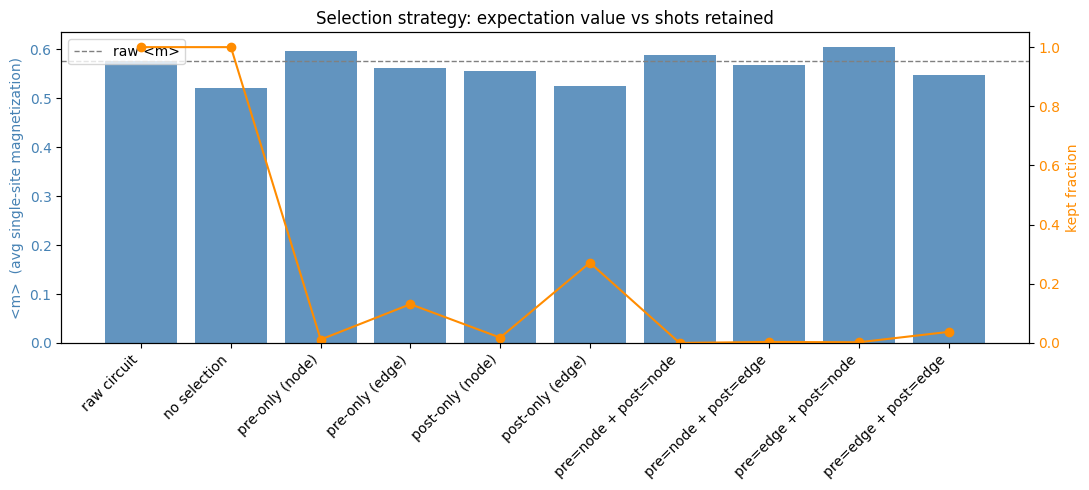

In [8]:
import matplotlib.pyplot as plt
from qiskit_addon_utils.noise_management.bit_flip_checks import PostSelector

selector = PostSelector.from_circuit(combined_isa, backend.coupling_map)

exec_results = job.result()
# The Executor returns numpy arrays keyed by classical-register name, so each result item is
# already the {creg_name: ndarray} mapping that compute_mask expects -- no BitArray unpacking.
raw_bits = exec_results[0]["meas"]  # raw circuit, no checks
bits = exec_results[1]  # combined pre+post circuit

meas_bits = bits["meas"]
total = meas_bits[..., 0].size


def magnetization(b, mask=None):
    """Average single-site magnetization over the (optionally masked) measurement bits."""
    kept = b if mask is None else b[mask]
    return (1 - 2 * kept.astype(int)).mean()  # bit 0 -> +1, bit 1 -> -1


rows = []


def report(label, mask=None, b=meas_bits):
    """Record and print the magnetization and kept fraction for one selection strategy."""
    kept = b[..., 0].size if mask is None else int(mask.sum())
    ev = magnetization(b, mask)
    rows.append((label, ev, kept / total))
    print(f"{label:<24}: <m> = {ev:+.4f}   (kept {kept:>6}/{total})")


# Every pass combination is recoverable from this single run.
report("raw circuit", b=raw_bits)
report("no selection")
for s in ("node", "edge"):
    report(f"pre-only ({s})", selector.compute_mask(bits, s, mode="pre"))
for s in ("node", "edge"):
    report(f"post-only ({s})", selector.compute_mask(bits, s, mode="post"))
for pre_s in ("node", "edge"):
    for post_s in ("node", "edge"):
        keep = selector.compute_mask(bits, pre_s, mode="pre") & selector.compute_mask(
            bits, post_s, mode="post"
        )
        report(f"pre={pre_s} + post={post_s}", keep)

labels = [r[0] for r in rows]
evs = [r[1] for r in rows]
fracs = [r[2] for r in rows]
x = range(len(labels))

fig, ax1 = plt.subplots(figsize=(11, 5))

# Bars: expectation value per selection strategy.
ax1.bar(x, evs, color="steelblue", alpha=0.85)
ax1.axhline(rows[0][1], color="gray", ls="--", lw=1, label="raw <m>")  # raw baseline
ax1.set_ylabel("<m>  (avg single-site magnetization)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.legend(loc="upper left")

# Line: fraction of shots retained (right axis).
ax2 = ax1.twinx()
ax2.plot(x, fracs, "o-", color="darkorange")
ax2.set_ylabel("kept fraction", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 1.05)

ax1.set_title("Selection strategy: expectation value vs shots retained")
fig.tight_layout()
plt.show()